In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import seaborn as sns
from datasets import *

2025-03-18 13:40:29.955787: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-18 13:40:29.962605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742330429.970555  139541 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742330429.972993  139541 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-18 13:40:29.981423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
dataset = BinaryDataset('Node123_loop')
# Example usage with random data
pre_outage_data = dataset.data_df.values
post_outage_data = dataset.data_outage_df.values

normal_len = pre_outage_data.shape[0]
outage_len = post_outage_data.shape[0]

In [3]:
# 合并数据
data = np.vstack([pre_outage_data, post_outage_data])
labels = np.array(dataset.labels.squeeze())  # 0 表示正常数据，1 表示故障数据

# **t-SNE 降维**
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(data)

# **UMAP 降维**
umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = umap_reducer.fit_transform(data)

# 计算t-SNE / UMAP 空间中的偏移量（故障前后数据的均值变化）
tsne_pre = tsne_results[:normal_len]
tsne_post = tsne_results[outage_len:]
umap_pre = umap_results[:normal_len]
umap_post = umap_results[outage_len:]

# 计算每个 bus 在故障前后的均值变化
tsne_shift = np.mean(tsne_post, axis=0) - np.mean(tsne_pre, axis=0)
umap_shift = np.mean(umap_post, axis=0) - np.mean(umap_pre, axis=0)

# 计算每个 bus 对应的 feature shift
feature_shift = np.abs(post_outage_data.mean(axis=0) - pre_outage_data.mean(axis=0))
outage_buses = np.argsort(feature_shift)[::-1] + 2

# **打印故障检测结果**
print("Outage Bus ID:", outage_buses)

/home/xiangyu/.conda/envs/PyTc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Outage Bus ID: [ 74  75  76  77 120 123 119 122 121 118 117 116 113 115 114 110 109 111
 112 108 104 107 103 105 106 101  97  84  85  90  94  83  96  98  99 102
  93  95  89  92  88 100  91  87  82  86  80  81  79  73  78  66  68  67
  70  69  65  71  72  63  64  62  60  61  59  58  57  38  26  53  47  43
  46  54  52  49  33  51  30  35  39  28  34  36  50  19  23  29  27  56
  22  24  20  32  21  44  25  42  18  41  45  48  37  15  16  40  17  55
  31  10  12  11  13  14   9   8   7   4   3   6   5   2]


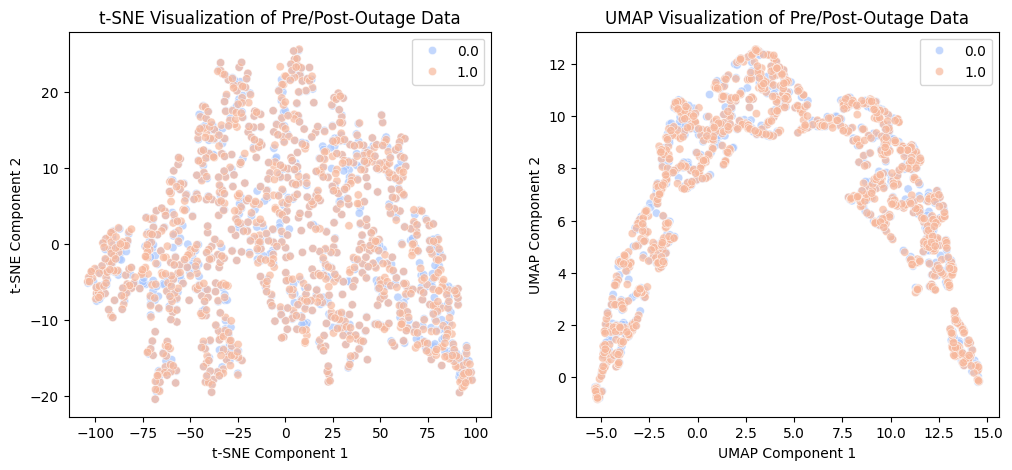

In [4]:
# 绘制 t-SNE 结果
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=labels, palette="coolwarm", alpha=0.7)
plt.title("t-SNE Visualization of Pre/Post-Outage Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

# 绘制 UMAP 结果
plt.subplot(1, 2, 2)
sns.scatterplot(x=umap_results[:, 0], y=umap_results[:, 1], hue=labels, palette="coolwarm", alpha=0.7)
plt.title("UMAP Visualization of Pre/Post-Outage Data")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.show()